In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision.datasets import ImageFolder
import torchvision.transforms as transforms
from torch.utils.data import TensorDataset, DataLoader

import kagglehub

import time
import matplotlib.pyplot as plt

torch.manual_seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

c:\Users\Mike\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


cuda


In [3]:
#adjustable parameters
from AutoEncoder import Encoder

from Classifiers import NaiveClassifier, PretrainedClassifier

num_epochs   = 14
classifier_lr= 1e-4 #same lr for both to reduce confounding variables
encoder_lr   = 1e-4 
batch_size   = 256
num_classes  = 8    
latent_dim   = 256
weight_decay = 1e-4 #to reduce overfitting

criterion = nn.CrossEntropyLoss()

weights = torch.load("models\\oct_encoder.pth", map_location=device)
dynamic_encoder = Encoder(latent_dim=latent_dim)
dynamic_encoder.load_state_dict(weights)
dynamic_encoder = dynamic_encoder.to(device)

naive_classifier = NaiveClassifier(num_classes).to(device)
pretrained_classifier = PretrainedClassifier(latent_dim, num_classes).to(device)

naive_optimizer = optim.Adam(naive_classifier.parameters(), lr=classifier_lr, weight_decay=weight_decay)
pretrained_optimizer = optim.Adam([
    {"params": dynamic_encoder.parameters(), 'lr': encoder_lr},
    {'params': pretrained_classifier.parameters(), 'lr': classifier_lr}
], weight_decay=weight_decay)

Data Configuration

In [4]:
#importing images
transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

#one pathology per image / equal number of images per pathology
full_dataset = kagglehub.dataset_download("obulisainaren/retinal-oct-c8")
full_dataset += '/RetinalOCT_Dataset/RetinalOCT_Dataset' 
train_dataset = ImageFolder(
    root=full_dataset+'/train',
    transform=transform
)

train_loader = DataLoader(
   dataset=train_dataset,
   batch_size=batch_size,
   shuffle=True,
   #increases compute speed
   num_workers=8,
   pin_memory=True,
   persistent_workers=True
)

val_dataset = ImageFolder(
    root= full_dataset+'/val',
    transform=transform
)

#val
val_loader = DataLoader(
   dataset=val_dataset,
   batch_size=batch_size,
   shuffle=False,
   #increases compute speed
   num_workers=8,
   pin_memory=True,
   persistent_workers=True
)

#test
test_dataset = ImageFolder(
    root= full_dataset+'/test',
    transform=transform
)

test_loader = DataLoader(
   dataset=test_dataset,
   batch_size=batch_size,
   shuffle=False,
   #increases compute speed
   num_workers=8,
   pin_memory=True,
   persistent_workers=True
)

Training

In [ ]:
#training pretrained - classifier: 2 linear layers
start_time = time.perf_counter()

#boosting accuracy
#scheduler = optim.lr_scheduler.CosineAnnealingLR(pretrained_optimizer, T_max=num_epochs)

pretrained_train_losses = []
pretrained_val_losses = []

for epoch in range(num_epochs):
    dynamic_encoder.train()
    pretrained_classifier.train()

    total_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        pretrained = dynamic_encoder(images)

        output = pretrained_classifier(pretrained)
        loss = criterion(output, labels)

        pretrained_optimizer.zero_grad()
        loss.backward()
        pretrained_optimizer.step()

        total_loss += loss.item()

        predicted = output.argmax(dim=1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    epoch_train_loss = total_loss / len(train_loader)
    accuracy = 100 * correct / total
    end_time = time.perf_counter()
    pretrained_train_losses.append(epoch_train_loss)
    

    #val
    pretrained_classifier.eval()

    val_loss = 0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            
            pretrained = dynamic_encoder(images)
            output = pretrained_classifier(pretrained)
            loss = criterion(output, labels)
            
            val_loss += loss.item()

            predicted = output.argmax(dim=1)

            val_correct += (predicted == labels).sum().item()
            val_total += labels.size(0)

    epoch_val_loss = val_loss / len(val_loader)
    epoch_val_accuracy = 100 * val_correct / val_total
    pretrained_val_losses.append(epoch_val_loss)
    #scheduler.step()

    print(
        f"Epoch {epoch+1}: "
        f"Training: Loss={epoch_train_loss:.4f}, "
        f"Accuracy={accuracy:.2f}%      "
        f"Validation: Loss={epoch_val_loss:.4f}, "
        f"Val Acc={epoch_val_accuracy:.2f}%"
    )
    


pretrained_accuracy = epoch_val_accuracy
pretrained_train_time = end_time - start_time

print(
    f"Results: Accuracy={pretrained_accuracy:.2f}% "
    f"Training Duration={pretrained_train_time:.6f} sec"
)

Epoch 1: Training: Loss=1.3961, Accuracy=38.54%      Validation: Loss=1.0991, Val Acc=50.14%
Epoch 2: Training: Loss=1.0938, Accuracy=50.24%      Validation: Loss=0.9720, Val Acc=58.21%
Epoch 3: Training: Loss=0.9771, Accuracy=57.21%      Validation: Loss=0.8785, Val Acc=62.96%
Epoch 4: Training: Loss=0.8785, Accuracy=62.30%      Validation: Loss=0.8210, Val Acc=63.96%
Epoch 5: Training: Loss=0.8038, Accuracy=66.72%      Validation: Loss=0.7707, Val Acc=67.46%
Epoch 6: Training: Loss=0.7364, Accuracy=69.49%      Validation: Loss=0.7203, Val Acc=69.82%
Epoch 7: Training: Loss=0.6818, Accuracy=72.48%      Validation: Loss=0.7056, Val Acc=70.96%
Epoch 8: Training: Loss=0.6359, Accuracy=74.91%      Validation: Loss=0.6666, Val Acc=72.57%
Epoch 9: Training: Loss=0.5966, Accuracy=76.81%      Validation: Loss=0.6428, Val Acc=74.46%
Epoch 10: Training: Loss=0.5705, Accuracy=77.46%      Validation: Loss=0.6275, Val Acc=75.14%
Epoch 11: Training: Loss=0.5349, Accuracy=79.12%      Validation: Los

In [61]:
torch.save(dynamic_encoder.state_dict(), "models/dynamic_encoder.pth")
torch.save(pretrained_classifier.state_dict(), "models/finetuned_classifier.pth")

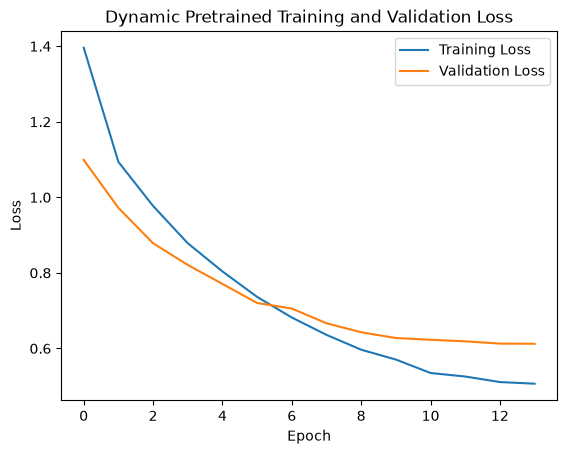

In [73]:
plt.plot(pretrained_train_losses, label="Training Loss")
plt.plot(pretrained_val_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Dynamic Pretrained Training and Validation Loss")
plt.legend()
plt.show()

Testing

In [7]:
#test - pretrained

from Classifiers import PretrainedClassifier
from AutoEncoder import Encoder


test_encoder = Encoder(latent_dim=latent_dim).to(device)
test_encoder.load_state_dict(torch.load("models/dynamic_encoder.pth", map_location=device))
test_encoder.eval()

test_pretrained_classifier = PretrainedClassifier(256, 8).to(device)
test_pretrained_classifier.load_state_dict(torch.load("models/finetuned_classifier.pth", map_location=device))
test_pretrained_classifier.eval()

#test_encoder = dynamic_encoder
#test_pretrained_classifier = pretrained_classifier


pretrained_correct = 0
total = 0
top2_correct = 0
conf_right, conf_wrong = 0.0, 0.0
n_wrong = 0
pretrained_class_correct = {c: 0 for c in range(num_classes)}
class_total = {c: 0 for c in range(num_classes)}

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)

        encoded = test_encoder(images)
        logits = test_pretrained_classifier(encoded)

        #raw scores -> probabilities that sum to 1
        probs = torch.softmax(logits, dim=1)
        conf, pretrained_predict = probs.max(dim=1)

        #was the right answer in the top 2 guesses
        top2 = probs.topk(2, dim=1).indices
        top2_correct += (top2 == labels.unsqueeze(1)).any(dim=1).sum().item()

        #margin: how far ahead the winner is, instead of how much mass it holds
        conf = probs.topk(2, dim=1).values.diff(dim=1).abs().squeeze(1)

        #which predictions were right
        hit = (pretrained_predict == labels)
        pretrained_correct += hit.sum().item()
        total += labels.size(0)

        #confidence split by right vs wrong
        conf_right += conf[hit].sum().item()
        conf_wrong += conf[~hit].sum().item()
        n_wrong += (~hit).sum().item()

        #tally each class separately
        for label, e_pred in zip(labels, pretrained_predict):
            l = label.item()
            class_total[l] += 1
            pretrained_class_correct[l] += int(l == e_pred.item())

print(f"Dynamic Pretrained test accuracy: {100 * pretrained_correct / total:.2f}%")
print(f"Top-2 accuracy:                   {100 * top2_correct / total:.2f}%")
print(f"Confidence when right:            {100 * conf_right / pretrained_correct:.2f}%")
print(f"Confidence when wrong:            {100 * conf_wrong / n_wrong:.2f}%")
print()
print(f"{'Class':<10} {'Dynamic Pretrained':>10}")
for c in range(num_classes):
    name = test_dataset.classes[c]
    e_acc = 100 * pretrained_class_correct[c] / class_total[c]
    print(f"{name:<10} {e_acc:>9.2f}%")

Dynamic Pretrained test accuracy: 76.50%
Top-2 accuracy:                   92.39%
Confidence when right:            76.50%
Confidence when wrong:            39.63%

Class      Dynamic Pretrained
AMD           100.00%
CNV            71.43%
CSR            91.71%
DME            69.43%
DR             76.86%
DRUSEN         55.43%
MH             85.71%
NORMAL         61.43%


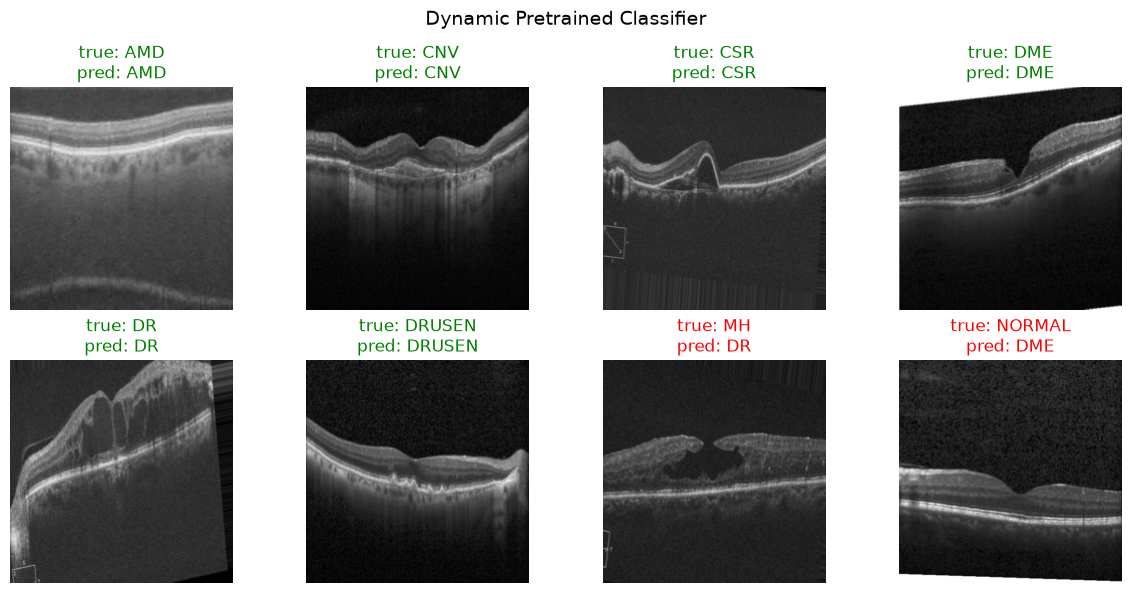

In [10]:
#visualizing results
found = {}
for images, labels in test_loader:
    for img, lab in zip(images, labels):
        c = lab.item()
        if c not in found:
            found[c] = img
    if len(found) == 8:
        break

true_ids = sorted(found)
batch = torch.stack([found[c] for c in true_ids])

test_pretrained_classifier.eval()
with torch.no_grad():
    features = test_encoder(batch.to(device))
    pred_ids = test_pretrained_classifier(features).argmax(dim=1).cpu().tolist()

class_names = test_loader.dataset.classes

fig, axes = plt.subplots(2, 4, figsize=(12, 6))
fig.suptitle("Dynamic Pretrained Classifier", fontsize=14)

for ax, t, p in zip(axes.flat, true_ids, pred_ids):
    ax.imshow((found[t].squeeze() + 1) / 2, cmap='gray', vmin=0, vmax=1)
    ax.set_title(f"true: {class_names[t]}\npred: {class_names[p]}",
                 color='green' if t == p else 'red')
    ax.axis('off')

plt.tight_layout()
plt.savefig("result_images/dynamic_pretrained_results.png")
plt.show()